In [ ]:
# ============================================================
# 環境設定（Colab/ローカル共通）
# ============================================================
import os

# Google Earth Engineプロジェクト ID（ご自身のGEEプロジェクトIDに変更）
GEE_PROJECT = os.environ.get('GEE_PROJECT', 'your-ee-project-id')

# 出力ディレクトリ（Colabの場合は/content/drive/MyDrive/...、ローカルの場合は任意のパス）
OUTPUT_DIR = os.environ.get('OUTPUT_DIR', '/content/drive/MyDrive/Downscaling')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'GEE_PROJECT: {GEE_PROJECT}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


In [6]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from pathlib import Path
import re

In [7]:
def normalize_daily_index(df: pd.DataFrame, how="sum") -> pd.DataFrame:
    d = df.copy()
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()]
    d.index = d.index.tz_localize(None).normalize()
    if d.index.duplicated().any():
        if how == "sum":
            d = d.groupby(level=0).sum(numeric_only=True)
        elif how == "mean":
            d = d.groupby(level=0).mean(numeric_only=True)
        else:
            raise ValueError("how must be 'sum' or 'mean'")
    return d

In [8]:
def compute_correction_factors(df_obs, df_gcm, obs_col="obs"):
    df_gcm = df_gcm.copy()
    df_gcm.index = pd.to_datetime(df_gcm.index, errors="coerce")
    df_gcm = df_gcm[~df_gcm.index.isna()]
    gcm_cols = df_gcm.columns.tolist()

    df_obs = df_obs.copy()
    df_obs.index = pd.to_datetime(df_obs.index, errors="coerce")
    df_obs = df_obs[~df_obs.index.isna()]

    obs = df_obs[obs_col].reindex(df_gcm.index).fillna(0.0).clip(lower=0.0)
    df_raw = pd.concat([obs.rename("obs"), df_gcm], axis=1).fillna(0.0)

    # --- corr1（Ranked through all period）---
    obs_sorted = np.sort(df_raw["obs"].to_numpy())
    N = len(obs_sorted)
    df_corr1 = pd.DataFrame(index=np.arange(N), columns=gcm_cols, dtype=float)
    for col in gcm_cols:
        g = np.sort(df_raw[col].to_numpy())
        df_corr1[col] = np.divide(obs_sorted, g, out=np.zeros_like(obs_sorted, dtype=float), where=(g > 0))

    # --- corr2（Ranked in each month）---
    df_corr2 = {}
    for m in range(1, 13):
        dfm = df_raw[df_raw.index.month == m]
        obs_m = np.sort(dfm["obs"].to_numpy())
        Nm = len(obs_m)

        corr_m = pd.DataFrame(index=np.arange(Nm), columns=gcm_cols, dtype=float)
        for col in gcm_cols:
            g_m = np.sort(dfm[col].to_numpy())
            corr_m[col] = np.divide(obs_m, g_m, out=np.zeros_like(obs_m, dtype=float), where=(g_m > 0))
        df_corr2[m] = corr_m

    # ---Threshould the zero precipitation day ---
    zero_count = int((df_raw["obs"] == 0).sum())

    df_adj_temp = df_raw[gcm_cols].copy()
    for m in range(1, 13):
        dfm = df_raw[df_raw.index.month == m]
        if len(dfm) == 0:
            continue
        Nm = len(dfm)
        for col in gcm_cols:
            idx_sorted = dfm[col].sort_values().index
            coeff = df_corr2[m][col].to_numpy()
            L = min(Nm, len(coeff))
            if L == 0:
                continue
            df_adj_temp.loc[idx_sorted[:L], col] = dfm.loc[idx_sorted[:L], col].to_numpy()[:L] * coeff[:L]

    zero_thresholds = {}
    for col in gcm_cols:
        vals = np.sort(df_adj_temp[col].to_numpy())
        if 1 <= zero_count <= len(vals):
            zero_thresholds[col] = float(vals[zero_count - 1])
        else:
            zero_thresholds[col] = 0.0

    return df_corr1, df_corr2, zero_thresholds


In [9]:
def apply_correction(df_target, df_corr1, df_corr2, zero_thresholds):
    df_target = df_target.copy()
    df_target.index = pd.to_datetime(df_target.index)
    gcm_cols = df_target.columns.tolist()

    # adj1：Rank collection in all periods
    df_adj1 = df_target.copy()
    for col in gcm_cols:
        idx_sorted = df_target[col].sort_values().index
        N = min(len(idx_sorted), len(df_corr1))
        coeff = df_corr1[col].to_numpy()[:N]
        df_adj1.loc[idx_sorted[:N], col] = df_target.loc[idx_sorted[:N], col].to_numpy()[:N] * coeff

    # adj2_1：Rank collection in each month
    df_adj2_1 = df_target.copy()
    for m in range(1, 13):
        dfm = df_target[df_target.index.month == m]
        if len(dfm) == 0:
            continue
        corr_m = df_corr2[m]
        for col in gcm_cols:
            if col not in corr_m.columns or len(corr_m) == 0:
                continue
            idx_sorted = dfm[col].sort_values().index
            coeff = corr_m[col].to_numpy()
            L = min(len(idx_sorted), len(coeff))
            if L == 0:
                continue
            df_adj2_1.loc[idx_sorted[:L], col] = dfm.loc[idx_sorted[:L], col].to_numpy()[:L] * coeff[:L]

    # adj2_2：0 precipitation data
    df_adj2_2 = df_adj2_1.copy()
    for col in gcm_cols:
        th = float(zero_thresholds.get(col, 0.0))
        df_adj2_2[col] = np.where(df_adj2_2[col].to_numpy() <= th, 0.0, df_adj2_2[col].to_numpy())

    # final
    df_final = df_target.copy()
    for col in gcm_cols:
        idx_sorted = df_target[col].sort_values().index
        k = int(np.floor(0.9 * len(idx_sorted)))
        df_final.loc[idx_sorted[k:], col] = df_adj1.loc[idx_sorted[k:], col]
        df_final.loc[idx_sorted[:k], col] = df_adj2_2.loc[idx_sorted[:k], col]

    return df_final

In [10]:
id_list = list(range(0,1))
ssp_list = ["ssp126", "ssp245", "ssp370", "ssp585"]

def find_best(root_dir: str, filename: str) -> str | None:
    hits = list(Path(root_dir).rglob(filename))
    if not hits:
        return None
    hits.sort(key=lambda p: p.stat().st_size, reverse=True)
    return str(hits[0])

def detect_ids_under_content() -> list[int]:
    obs_ids = set()
    his_ids = set()

    for p in Path("/content").rglob("his_obs_id_*.csv"):
        m = re.search(r"his_obs_id_(\d+)\.csv$", p.name)
        if m:
            obs_ids.add(int(m.group(1)))

    for p in Path("/content").rglob("his_id_*.csv"):
        if "his_corr" in str(p) or "_corrected" in p.name:
            continue
        m = re.search(r"his_id_(\d+)\.csv$", p.name)
        if m:
            his_ids.add(int(m.group(1)))

    return sorted(obs_ids & his_ids)

id_list = detect_ids_under_content()
print("Detected IDs:", id_list)

for id in id_list:
    obs_path = find_best("/content", f"his_obs_id_{id}.csv")
    his_path = find_best("/content", f"his_id_{id}.csv")

    if obs_path is None:
        print(f"⚠️ No obs file: his_obs_id_{id}.csv")
        continue
    if his_path is None:
        print(f"⚠️ No his file: his_id_{id}.csv")
        continue


    if not os.path.exists(obs_path):
        print(f"⚠️ No obs file: {obs_path}")
        continue
    if not os.path.exists(his_path):
        print(f"⚠️ No his file: {his_path}")
        continue

    # ---------
    # obs data loading with date and rain
    # ---------
    df_obs = pd.read_csv(obs_path).fillna(0)

    if "date" not in df_obs.columns or "Rain" not in df_obs.columns:
        print(f"⚠️ Obs column mismatch: {obs_path} columns={list(df_obs.columns)}")
        continue

    df_obs["date"] = pd.to_datetime(df_obs["date"], errors="coerce")
    df_obs = df_obs.dropna(subset=["date"])
    df_obs = df_obs.rename(columns={"Rain": "obs"}).set_index("date")[["obs"]]

    # ---------
    # GCM his loading
    # ---------
    df_his = pd.read_csv(his_path).fillna(0)
    df_his["date"] = pd.to_datetime(df_his["date"], errors="coerce")
    df_his = df_his.dropna(subset=["date"]).set_index("date")
    df_corr1, df_corr2, zero_thresholds = compute_correction_factors(df_obs, df_his, obs_col="obs")

    # his Correction
    his_corrected = apply_correction(df_his, df_corr1, df_corr2, zero_thresholds)
    os.makedirs("/content/his_corr", exist_ok=True)
    his_corrected.to_csv(f"/content/his_corr/his_id_{id}_corrected.csv")

     # fut Correction
    for ssp in ssp_list:
        fut_path = find_best("/content", f"fut_{ssp}_id_{id}.csv")
        if fut_path is None:
            print(f"⚠️ No File: fut_{ssp}_id_{id}.csv")
            continue

        out_path = f"/content/{ssp}_corr/fut_{ssp}_id_{id}_corrected.csv"

        df_fut = pd.read_csv(fut_path).fillna(0)
        if "date" not in df_fut.columns:
            raise ValueError(f"'date' column not found in {fut_path}. columns={list(df_fut.columns)}")

        df_fut["date"] = pd.to_datetime(df_fut["date"], errors="coerce")
        df_fut = df_fut.dropna(subset=["date"]).set_index("date")

        df_fut = normalize_daily_index(df_fut, how="sum")
        fut_corrected = apply_correction(df_fut, df_corr1, df_corr2, zero_thresholds)

        os.makedirs(f"/content/{ssp}_corr", exist_ok=True)
        fut_corrected.to_csv(out_path)


print("✅ done")


Detected IDs: [0]
⚠️ No File: fut_ssp245_id_0.csv
⚠️ No File: fut_ssp370_id_0.csv
✅ done


In [11]:
for folder in ["his_corr"] + [f"{ssp}_corr" for ssp in ssp_list]:
    if os.path.exists(f"/content/{folder}"):
        shutil.make_archive(f"/content/{folder}", "zip", f"/content/{folder}")
        files.download(f"/content/{folder}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

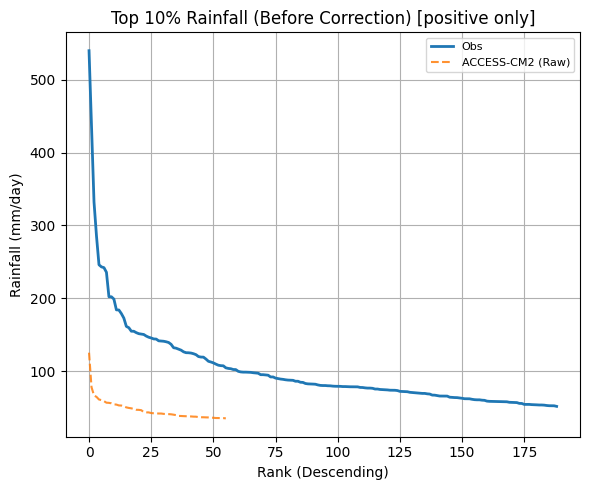

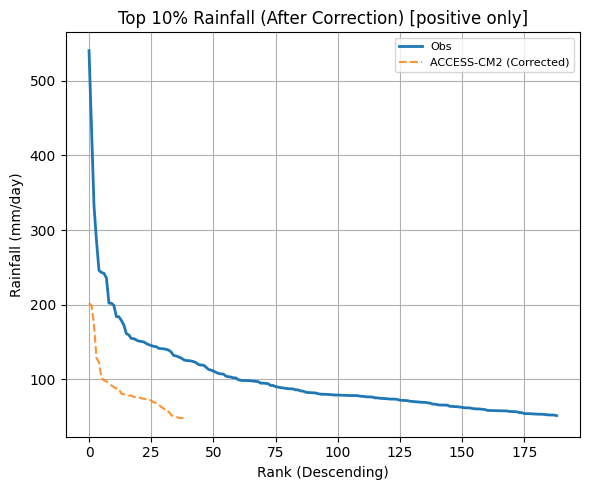

In [12]:
def get_top10_sorted(df, col, positive_only=True):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if positive_only:
        s = s[s > 0]
    s = s.sort_values(ascending=False).reset_index(drop=True)
    n = max(1, int(np.ceil(0.10 * len(s)))) if len(s) > 0 else 0
    return s.iloc[:n].reset_index(drop=True)

id0 = 0
if id0 not in id_list and len(id_list) > 0:
    id0 = id_list[0]

raw_path = find_best("/content", f"his_id_{id0}.csv")
obs_path = find_best("/content", f"his_obs_id_{id0}.csv")
corr_path = f"/content/his_corr/his_id_{id0}_corrected.csv"

if raw_path is None or obs_path is None or (not os.path.exists(corr_path)):
    raise FileNotFoundError(f"Plot files missing for id={id0}: raw={raw_path}, obs={obs_path}, corr={corr_path}")

# ---- his raw read ----
df_raw = pd.read_csv(raw_path).fillna(0)
raw_date_col = "date" if "date" in df_raw.columns else df_raw.columns[0]
df_raw[raw_date_col] = pd.to_datetime(df_raw[raw_date_col], errors="coerce")
df_raw = df_raw.dropna(subset=[raw_date_col]).set_index(raw_date_col)
df_raw = df_raw.apply(pd.to_numeric, errors="coerce").fillna(0)

# ---- corrected read ----
df_corr = pd.read_csv(corr_path, index_col=0).fillna(0)
df_corr.index = pd.to_datetime(df_corr.index, errors="coerce")
if df_corr.index.isna().any():
    df_corr = pd.read_csv(corr_path).fillna(0)
    cor_date_col = "date" if "date" in df_corr.columns else df_corr.columns[0]
    df_corr[cor_date_col] = pd.to_datetime(df_corr[cor_date_col], errors="coerce")
    df_corr = df_corr.dropna(subset=[cor_date_col]).set_index(cor_date_col)
df_corr = df_corr.apply(pd.to_numeric, errors="coerce").fillna(0)

# ---- obs read ----
df_obs0 = pd.read_csv(obs_path).fillna(0)
df_obs0["date"] = pd.to_datetime(df_obs0["date"], errors="coerce")
df_obs0 = df_obs0.dropna(subset=["date"])
if "Rain" not in df_obs0.columns:
    raise ValueError(f"'Rain' column not found in {obs_path}. columns={list(df_obs0.columns)}")
df_obs0 = df_obs0.rename(columns={"Rain": "obs"}).set_index("date")[["obs"]]
df_obs0["obs"] = pd.to_numeric(df_obs0["obs"], errors="coerce").fillna(0)

# ★期間が一致しないことがあるので common で削らない（Top10%はランキング比較でOK）
df_before = pd.concat([df_obs0, df_raw], axis=1)
df_after  = pd.concat([df_obs0, df_corr], axis=1)

obs_col = "obs"
gcm_cols = df_raw.columns.tolist()

plt.figure(figsize=(6, 5))
plt.title("Top 10% Rainfall (Before Correction) [positive only]")
plt.xlabel("Rank (Descending)")
plt.ylabel("Rainfall (mm/day)")
plt.grid(True)
plt.plot(get_top10_sorted(df_before, obs_col, positive_only=True), linewidth=2, label="Obs")
for col in gcm_cols:
    plt.plot(get_top10_sorted(df_before, col, positive_only=True), linestyle="--", alpha=0.85, label=f"{col} (Raw)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.title("Top 10% Rainfall (After Correction) [positive only]")
plt.xlabel("Rank (Descending)")
plt.ylabel("Rainfall (mm/day)")
plt.grid(True)
plt.plot(get_top10_sorted(df_after, obs_col, positive_only=True), linewidth=2, label="Obs")
for col in gcm_cols:
    plt.plot(get_top10_sorted(df_after, col, positive_only=True), linestyle="--", alpha=0.85, label=f"{col} (Corrected)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
import os

def list_files_in_dir(directory):
    if os.path.exists(directory):
        print(f"Files in {directory}:")
        for filename in os.listdir(directory):
            print(f"- {filename}")
    else:
        print(f"Directory {directory} does not exist.")

list_files_in_dir('/content/obs/')
list_files_in_dir('/content/his/')
for ssp in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:
    list_files_in_dir(f'/content/{ssp}/')


Directory /content/obs/ does not exist.
Directory /content/his/ does not exist.
Directory /content/ssp126/ does not exist.
Directory /content/ssp245/ does not exist.
Directory /content/ssp370/ does not exist.
Directory /content/ssp585/ does not exist.
